<a href="https://colab.research.google.com/github/TriBot2o/AI_And_ML_Year3/blob/main/2408947_RujanMaharjan_Code_Text_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Text Preprocessing, Tokenization, and Sequence Padding

### Necessary Imports

In [2]:
# Install necessary libraries
!pip install contractions

# Download NLTK data (stopwords, wordnet)
import nltk
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
print('NLTK stopwords and wordnet downloaded successfully.')

NLTK stopwords and wordnet downloaded successfully.


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import time
import os
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.models import load_model


### Checking the CSV content

In [4]:
df = pd.read_csv('/content/drive/MyDrive/AI ML/Data/6. News Category Dataset/news_category.csv')

# Display the first 5 rows of the DataFrame to verify loading
display(df.head())

,headline,category
0,How A New Documentary Captures The Complexity ...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS


In [5]:
# Inspect the unique values and their counts in the 'category' column
print("Unique categories and their counts:")
print(df['category'].value_counts())

# Also check the total number of unique categories
num_unique_categories = df['category'].nunique()
print(f"\nTotal number of unique categories: {num_unique_categories}")

Unique categories and their counts:
category
SPORTS            5077
TECH              2104
MONEY             1756
CULTURE & ARTS    1074
EDUCATION         1014
Name: count, dtype: int64

Total number of unique categories: 5


### Text Preprocessing Setup



In [6]:
# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Function to clean text
def clean_text(text):
    if not isinstance(text, str):
        return ''

    # 1. Handle contractions
    text = contractions.fix(text)

    # 2. Lowercase all text
    text = text.lower()

    # 3. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 4. Remove mentions (@user)
    text = re.sub(r'@\w+', '', text)

    # 5. Remove hashtags (#)
    text = re.sub(r'#\w+', '', text)

    # 6. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 7. Remove special characters (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 8. Remove stopwords and lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    text = ' '.join(tokens)

    # 9. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

print('Text cleaning function defined.')

Text cleaning function defined.


### Apply Text Preprocessing



In [7]:
df['clean_text'] = df['headline'].apply(clean_text)
display(df[['headline', 'clean_text']].head())

,headline,clean_text
0,How A New Documentary Captures The Complexity ...,new documentary capture complexity child immig...
1,Twitch Bans Gambling Sites After Streamer Scam...,twitch ban gambling site streamer scam folk
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,reboot clever navelgazey look inside tv reboots
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",maury will basestealing shortstop dodger dy
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",la vega ace win first wnba title chelsea gray ...


### Visualize Cleaned Data




20 Most Frequent Words:
video: 493
new: 458
photo: 428
nfl: 336
game: 333
world: 317
player: 306
school: 276
win: 268
apple: 252
say: 250
watch: 246
team: 224
get: 222
week: 222
facebook: 209
first: 205
yous: 205
football: 200
art: 199


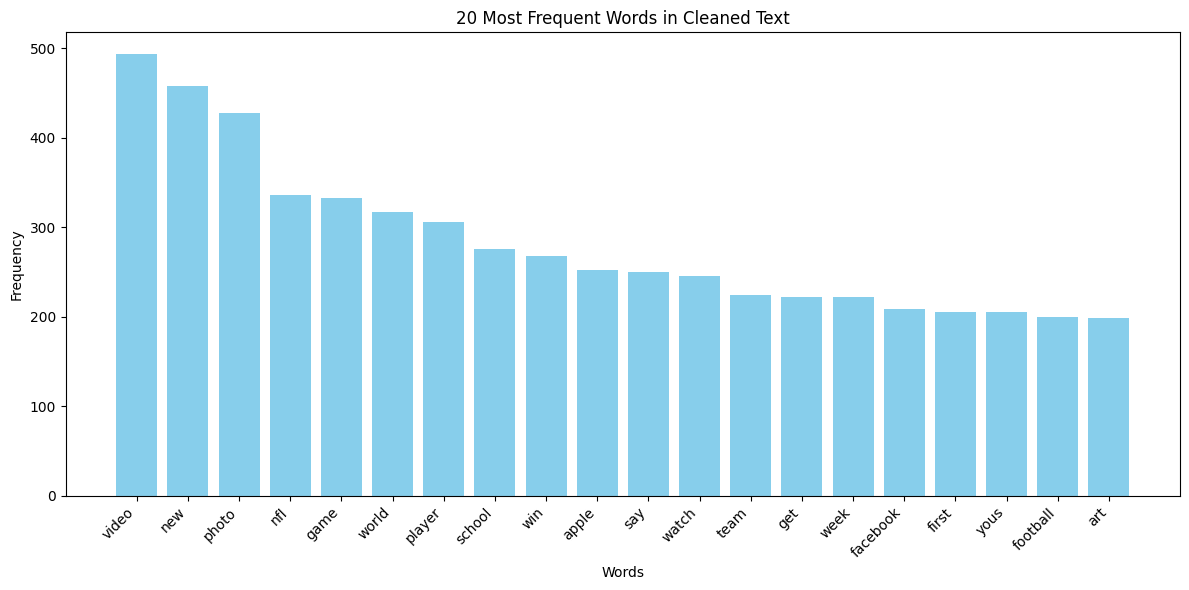

In [8]:
# Tokenize all cleaned text and count word frequencies
all_words = ' '.join(df['clean_text'].dropna().tolist()).split()
word_counts = Counter(all_words)

# Display the 20 most frequent words
most_common_words = word_counts.most_common(20)
print("\n20 Most Frequent Words:")
for word, count in most_common_words:
    print(f"{word}: {count}")

# You can also visualize these as a bar chart
words, counts = zip(*most_common_words)

plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='skyblue')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('20 Most Frequent Words in Cleaned Text')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Tokenization and Padding



In [9]:
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the 'category' column to get numerical labels
df['encoded_category'] = label_encoder.fit_transform(df['category'])

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['encoded_category'], test_size=0.2, random_state=42, stratify=df['encoded_category'] # Stratify by the encoded category
)

# Update num_classes based on the actual number of unique categories
num_classes = len(label_encoder.classes_)
print(f"Number of unique categories (num_classes): {num_classes}")

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
print("Data split into training and testing sets with encoded categories.")

Number of unique categories (num_classes): 5
Training set size: 8820
Testing set size: 2205
Data split into training and testing sets with encoded categories.


In [10]:
# Initialize Keras Tokenizer
# num_words: the maximum number of words to keep, based on word frequency.
# oov_token: a token to represent out-of-vocabulary words.
tokenizer = Tokenizer(num_words=10000, oov_token="<unk>") # You can adjust num_words

# Fit the tokenizer on the training text data
tokenizer.fit_on_texts(X_train)

print("Tokenizer fitted on training data.")
print(f"Number of unique tokens found: {len(tokenizer.word_index)}")

Tokenizer fitted on training data.
Number of unique tokens found: 12007


In [11]:
# Convert text to sequences of integers
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

print("Text converted to sequences of integers.")

# Determine maxlen for padding using percentile-based approach
# Calculate lengths of all sequences
all_sequence_lengths = [len(seq) for seq in X_train_sequences]

# Determine maxlen as the 90th percentile of sequence lengths
# This helps avoid excessively long sequences caused by outliers
max_sequence_len = int(np.percentile(all_sequence_lengths, 90))
print(f"Determined max sequence length (90th percentile): {max_sequence_len}")

X_train_padded = pad_sequences(X_train_sequences, maxlen=max_sequence_len, padding='pre')
X_test_padded = pad_sequences(X_test_sequences, maxlen=max_sequence_len, padding='pre')

print("Sequences padded to uniform length.")
print(f"Shape of X_train_padded: {X_train_padded.shape}")
print(f"Shape of X_test_padded: {X_test_padded.shape}")

# Display a sample of original sequence vs. padded sequence
print("\nSample original sequence (first training example):", X_train_sequences[0])
print("Sample padded sequence (first training example):", X_train_padded[0])

Text converted to sequences of integers.
Determined max sequence length (90th percentile): 10
Sequences padded to uniform length.
Shape of X_train_padded: (8820, 10)
Shape of X_test_padded: (2205, 10)

Sample original sequence (first training example): [64, 66, 11, 369, 2122, 777]
Sample padded sequence (first training example): [   0    0    0    0   64   66   11  369 2122  777]


## Model Building and Training

###  Simple RNN with a trainable Embedding layer

In [12]:
# Define model parameters
vocab_size = len(tokenizer.word_index) + 1  # +1 for padding token
embedding_dim = 100  # Dimension of the word embeddings
input_length = max_sequence_len  # Length of input sequences after padding

# Build the Simple RNN model
rnn_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_shape=(input_length,)),
    SimpleRNN(units=128),  # SimpleRNN layer with 128 units
    Dense(num_classes, activation='softmax') # Output layer for multi-class classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
# Compile the model
rnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Display model summary
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 10, 100)        │     1,200,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        29,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,230,757 (4.69 MB)

 Trainable params: 1,230,757 (4.69 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Convert y_train and y_test to float32
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')

# Define Early Stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_save_dir = '/content/drive/MyDrive/AI ML/Models/'

# Define Model Checkpoint callback
model_checkpoint = ModelCheckpoint(
    filepath= os.path.join(model_save_dir, 'best_RNN_model.keras'),
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# Record start time
start_time = time.time()

# Train the model
history = rnn_model.fit(
    X_train_padded,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2, # Use 20% of training data for validation
    callbacks=[early_stopping, model_checkpoint]
)

# Record end time and calculate duration
end_time = time.time()
training_duration = end_time - start_time

print("Simple RNN model training complete.")
print(f"Training took {training_duration:.2f} seconds.")

Epoch 1/15
220/221 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5350 - loss: 1.2098
Epoch 1: val_loss improved from None to 0.58700, saving model to /content/drive/MyDrive/AI ML/Models/best_RNN_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI ML/Models/best_RNN_model.keras
221/221 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.6351 - loss: 0.9700 - val_accuracy: 0.7897 - val_loss: 0.5870
Epoch 2/15
220/221 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9022 - loss: 0.3115
Epoch 2: val_loss improved from 0.58700 to 0.51307, saving model to /content/drive/MyDrive/AI ML/Models/best_RNN_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AI ML/Models/best_RNN_model.keras
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9141 - loss: 0.2717 - val_accuracy: 0.8203 - val_loss: 0.5131
Epoch 3/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9818 - loss: 0.0756
Epoch 3: val_loss did not improve from 0.51307
221/221 ━━━━━━━━━━━━━━━━

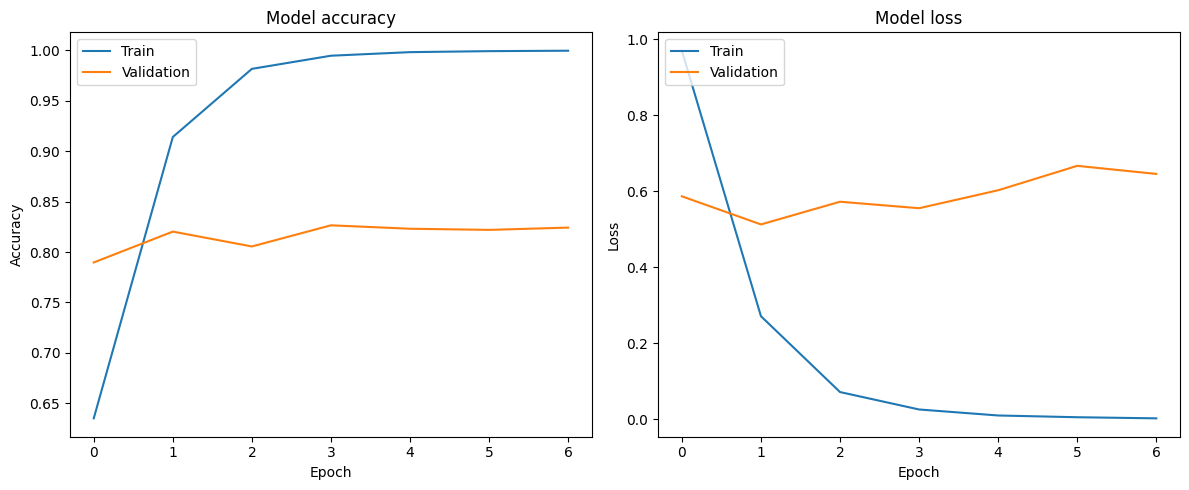

In [15]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

#### RNN Model Evaluation

In [16]:
# Load the best Simple RNN model
loaded_rnn_model = load_model(os.path.join(model_save_dir, 'best_RNN_model.keras'))

# Make predictions on the test set using the loaded model
y_pred_proba = loaded_rnn_model.predict(X_test_padded)
# For multi-class classification, get the class with the highest probability
y_pred = np.argmax(y_pred_proba, axis=1)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Generate Classification Report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Accuracy: 0.8190

Classification Report:
              precision    recall  f1-score   support

         0.0       0.76      0.60      0.67       215
         1.0       0.67      0.69      0.68       203
         2.0       0.87      0.64      0.74       351
         3.0       0.84      0.96      0.90      1015
         4.0       0.84      0.79      0.81       421

    accuracy                           0.82      2205
   macro avg       0.79      0.74      0.76      2205
weighted avg       0.82      0.82      0.81      2205



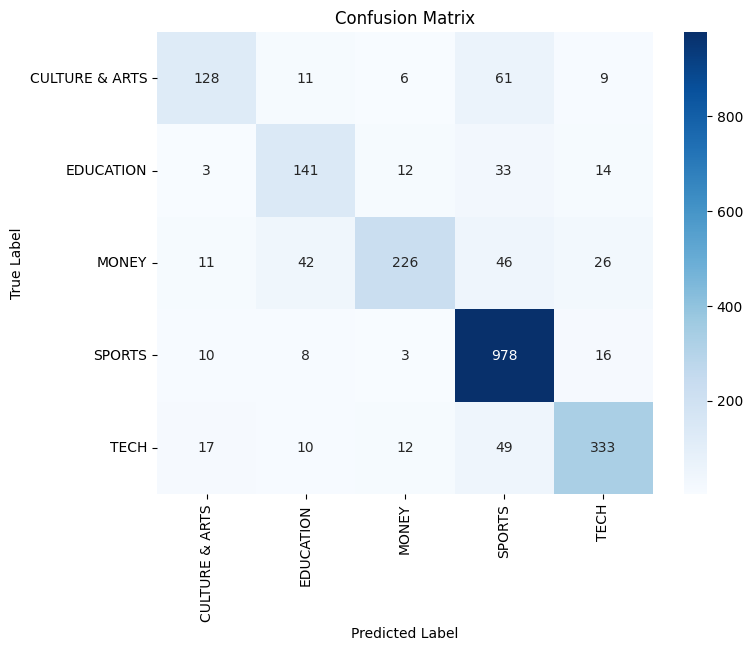

In [17]:
# Generate Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Get class names from the LabelEncoder (assuming it's still available)
# If label_encoder is not available, you might need to re-initialize it or use generic labels
class_names = label_encoder.classes_ if 'label_encoder' in locals() else [str(i) for i in range(num_classes)]

plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### LSTM with a trainable Embedding layer

In [18]:
# Build the LSTM model
lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_shape=(input_length,)),
    tf.keras.layers.LSTM(units=128),  # LSTM layer with 128 units
    Dense(num_classes, activation='softmax') # Output layer for multi-class classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
# Compile the LSTM model
lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Display model summary
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 10, 100)        │     1,200,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,318,693 (5.03 MB)

 Trainable params: 1,318,693 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model_checkpoint_LSTM = ModelCheckpoint(
    filepath= os.path.join(model_save_dir, 'best_LSTM_model.keras'),
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# Record start time
start_time_lstm = time.time()

# Train the LSTM model
history_lstm = lstm_model.fit(
    X_train_padded,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, model_checkpoint_LSTM]
)

# Record end time and calculate duration
end_time_lstm = time.time()
training_duration_lstm = end_time_lstm - start_time_lstm

print("LSTM model training complete.")
print(f"Training took {training_duration_lstm:.2f} seconds.")

Epoch 1/15
220/221 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5252 - loss: 1.2393
Epoch 1: val_loss improved from None to 0.56610, saving model to /content/drive/MyDrive/AI ML/Models/best_LSTM_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI ML/Models/best_LSTM_model.keras
221/221 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.6325 - loss: 0.9624 - val_accuracy: 0.8084 - val_loss: 0.5661
Epoch 2/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8872 - loss: 0.3457
Epoch 2: val_loss improved from 0.56610 to 0.45442, saving model to /content/drive/MyDrive/AI ML/Models/best_LSTM_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AI ML/Models/best_LSTM_model.keras
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.8999 - loss: 0.3093 - val_accuracy: 0.8475 - val_loss: 0.4544
Epoch 3/15
219/221 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9717 - loss: 0.1014
Epoch 3: val_loss did not improve from 0.45442
221/221 ━━━━━━━━━━━━

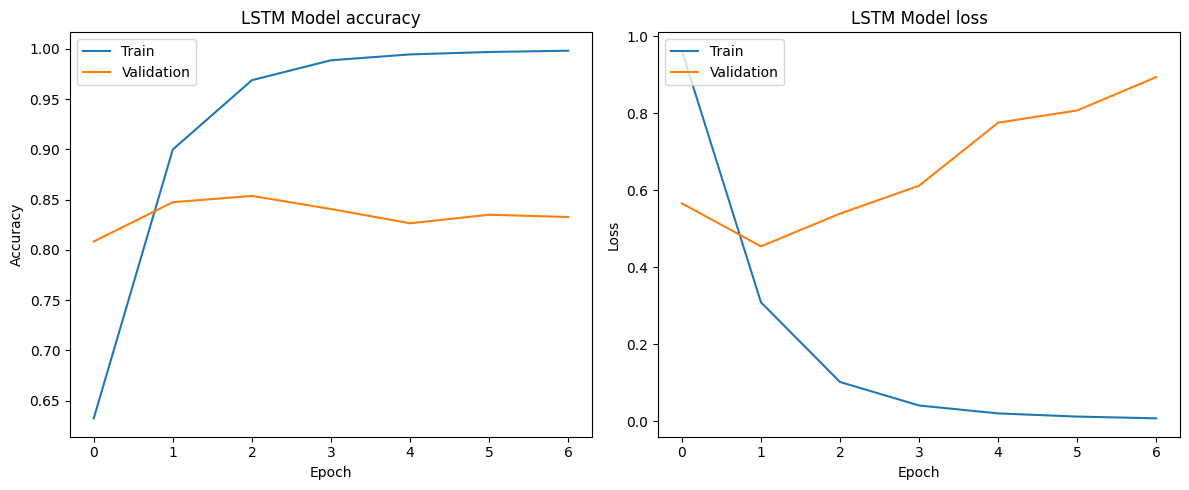

In [21]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values for LSTM
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['accuracy'])
plt.plot(history_lstm.history['val_accuracy'])
plt.title('LSTM Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values for LSTM
plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])
plt.title('LSTM Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

#### LSTM Model Evaluation

In [22]:

# Load the best LSTM model
loaded_lstm_model = load_model(os.path.join(model_save_dir, 'best_LSTM_model.keras'))

# Make predictions on the test set using the loaded LSTM model
y_pred_proba_lstm = loaded_lstm_model.predict(X_test_padded)
# For multi-class classification, get the class with the highest probability
y_pred_lstm = np.argmax(y_pred_proba_lstm, axis=1)

# Calculate Accuracy for LSTM
accuracy_lstm = accuracy_score(y_test, y_pred_lstm)
print(f"LSTM Model Accuracy: {accuracy_lstm:.4f}")

# Generate Classification Report for LSTM
class_report_lstm = classification_report(y_test, y_pred_lstm)
print("\nLSTM Model Classification Report:")
print(class_report_lstm)

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
LSTM Model Accuracy: 0.8481

LSTM Model Classification Report:
              precision    recall  f1-score   support

         0.0       0.76      0.76      0.76       215
         1.0       0.83      0.72      0.77       203
         2.0       0.84      0.74      0.78       351
         3.0       0.91      0.93      0.92      1015
         4.0       0.76      0.84      0.80       421

    accuracy                           0.85      2205
   macro avg       0.82      0.80      0.81      2205
weighted avg       0.85      0.85      0.85      2205



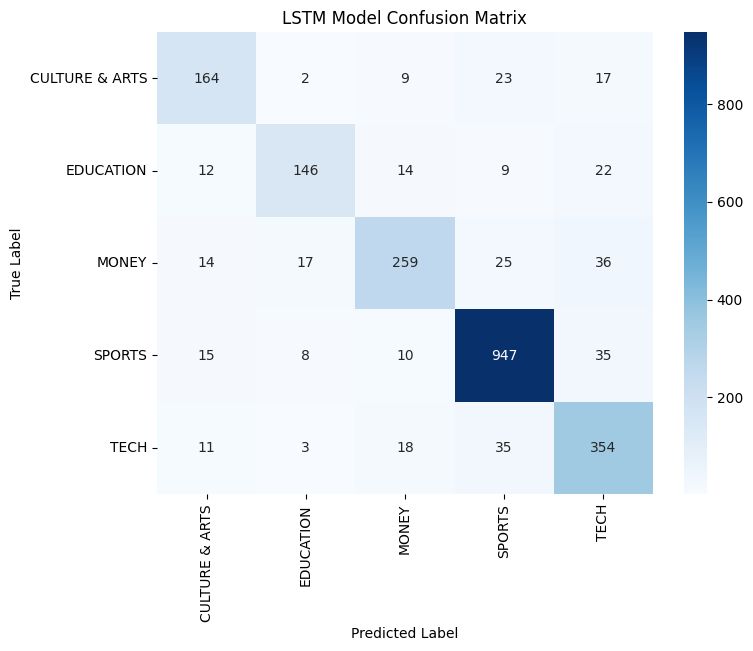

In [23]:
import seaborn as sns

# Generate Confusion Matrix for LSTM
conf_matrix_lstm = confusion_matrix(y_test, y_pred_lstm)

# Get class names from the LabelEncoder (assuming it's still available)
class_names = label_encoder.classes_ if 'label_encoder' in locals() else [str(i) for i in range(num_classes)]

plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix_lstm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('LSTM Model Confusion Matrix')
plt.show()

### LSTM with pretrained Word2Vec embeddings

#### Download and Load Pretrained GloVe Embeddings (100-dim)

In [24]:
# Install gensim if not already installed
!pip install gensim

import gensim.downloader as api

# Download the pre-trained GloVe model (glove-wiki-gigaword-100 has 100 dimensions)
# This might take some time and consume a few MB of disk space
print("Downloading GloVe model (glove-wiki-gigaword-100). This may take a while...")
word2vec_model = api.load("glove-wiki-gigaword-100")
print("GloVe model loaded successfully.")

[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe model loaded successfully.


#### Create an Embedding Matrix (GloVe 100-dim)

In [25]:
# Define the embedding dimension for the GloVe model
word2vec_embedding_dim = 100 # As 'glove-wiki-gigaword-100' has 100 dimensions

# Create an embedding matrix
embedding_matrix_w2v = np.zeros((vocab_size, word2vec_embedding_dim))
for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        if word in word2vec_model:
            embedding_matrix_w2v[i] = word2vec_model[word]
        else:
            # Words not found in GloVe will be initialized as all zeros
            embedding_matrix_w2v[i] = np.zeros(word2vec_embedding_dim)

print("Embedding matrix for GloVe created.")

Embedding matrix for GloVe created.


#### Build the LSTM Model with Pretrained GloVe 100-dim Embeddings

In [26]:
# Build the LSTM model with pretrained GloVe embeddings
lstm_w2v_model = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=word2vec_embedding_dim, # Use 100 for glove-wiki-gigaword-100
              input_length=input_length,
              weights=[embedding_matrix_w2v], # Use the pretrained embeddings
              trainable=False), # Set to False to keep embeddings fixed
    tf.keras.layers.LSTM(units=128),  # LSTM layer with 128 units
    Dense(num_classes, activation='softmax') # Output layer for multi-class classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [27]:
# Compile the LSTM model with Word2Vec embeddings
lstm_w2v_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Display model summary
lstm_w2v_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,200,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,200,800 (4.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,200,800 (4.58 MB)

In [28]:

# Define Model Checkpoint callback for this model
model_checkpoint_w2v = ModelCheckpoint(
    filepath= os.path.join(model_save_dir, 'best_LSTM_Word2Vec_model.keras'),
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# Record start time
start_time_lstm_w2v = time.time()

# Train the LSTM model
history_lstm_w2v = lstm_w2v_model.fit(
    X_train_padded,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, model_checkpoint_w2v]
)

# Record end time and calculate duration
end_time_lstm_w2v = time.time()
training_duration_lstm_w2v = end_time_lstm_w2v - start_time_lstm_w2v

print("LSTM model with Word2Vec embeddings training complete.")
print(f"Training took {training_duration_lstm_w2v:.2f} seconds.")

Epoch 1/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6889 - loss: 0.8340
Epoch 1: val_loss improved from None to 0.47945, saving model to /content/drive/MyDrive/AI ML/Models/best_LSTM_Word2Vec_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI ML/Models/best_LSTM_Word2Vec_model.keras
221/221 ━━━━━━━━━━━━━━━━━━━━ 17s 66ms/step - accuracy: 0.7827 - loss: 0.6255 - val_accuracy: 0.8288 - val_loss: 0.4794
Epoch 2/15
218/221 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8588 - loss: 0.4243
Epoch 2: val_loss improved from 0.47945 to 0.45111, saving model to /content/drive/MyDrive/AI ML/Models/best_LSTM_Word2Vec_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AI ML/Models/best_LSTM_Word2Vec_model.keras
221/221 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - accuracy: 0.8543 - loss: 0.4299 - val_accuracy: 0.8379 - val_loss: 0.4511
Epoch 3/15
220/221 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8723 - loss: 0.3723
Epoch 3: val_loss improved fro

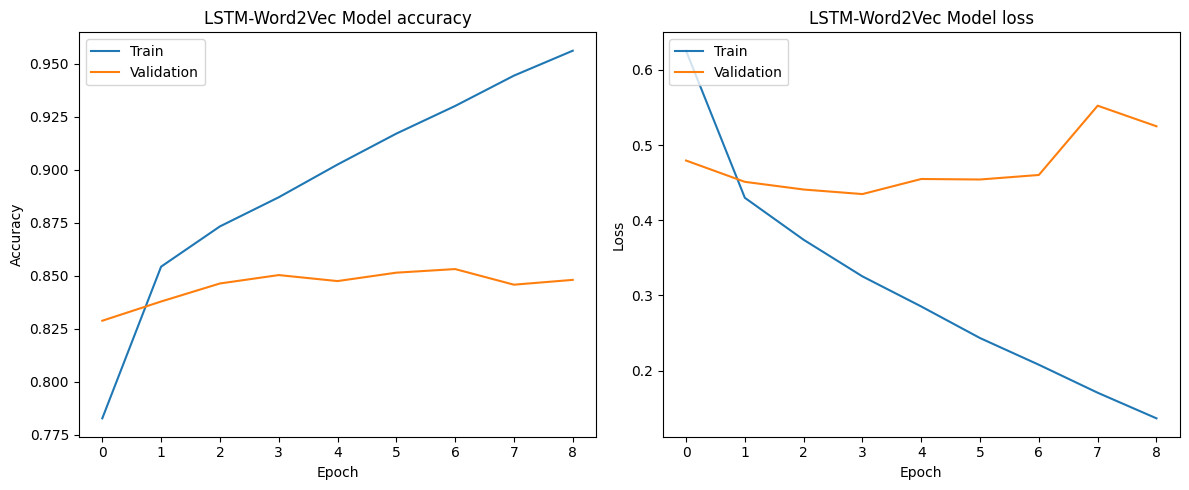

In [29]:
# Plot training & validation accuracy values for LSTM-Word2Vec
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_lstm_w2v.history['accuracy'])
plt.plot(history_lstm_w2v.history['val_accuracy'])
plt.title('LSTM-Word2Vec Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values for LSTM-Word2Vec
plt.subplot(1, 2, 2)
plt.plot(history_lstm_w2v.history['loss'])
plt.plot(history_lstm_w2v.history['val_loss'])
plt.title('LSTM-Word2Vec Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

#### LSTM-Word2Vec Model Evaluation

In [30]:

# Load the best LSTM with Word2Vec model
loaded_lstm_w2v_model = load_model(os.path.join(model_save_dir, 'best_LSTM_Word2Vec_model.keras'))

# Make predictions on the test set using the loaded LSTM-Word2Vec model
y_pred_proba_lstm_w2v = loaded_lstm_w2v_model.predict(X_test_padded)
# For multi-class classification, get the class with the highest probability
y_pred_lstm_w2v = np.argmax(y_pred_proba_lstm_w2v, axis=1)

# Calculate Accuracy for LSTM-Word2Vec
accuracy_lstm_w2v = accuracy_score(y_test, y_pred_lstm_w2v)
print(f"LSTM-Word2Vec Model Accuracy: {accuracy_lstm_w2v:.4f}")

# Generate Classification Report for LSTM-Word2Vec
class_report_lstm_w2v = classification_report(y_test, y_pred_lstm_w2v)
print("\nLSTM-Word2Vec Model Classification Report:")
print(class_report_lstm_w2v)

69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
LSTM-Word2Vec Model Accuracy: 0.8567

LSTM-Word2Vec Model Classification Report:
              precision    recall  f1-score   support

         0.0       0.75      0.78      0.77       215
         1.0       0.76      0.74      0.75       203
         2.0       0.80      0.81      0.81       351
         3.0       0.92      0.93      0.92      1015
         4.0       0.86      0.82      0.84       421

    accuracy                           0.86      2205
   macro avg       0.82      0.82      0.82      2205
weighted avg       0.86      0.86      0.86      2205



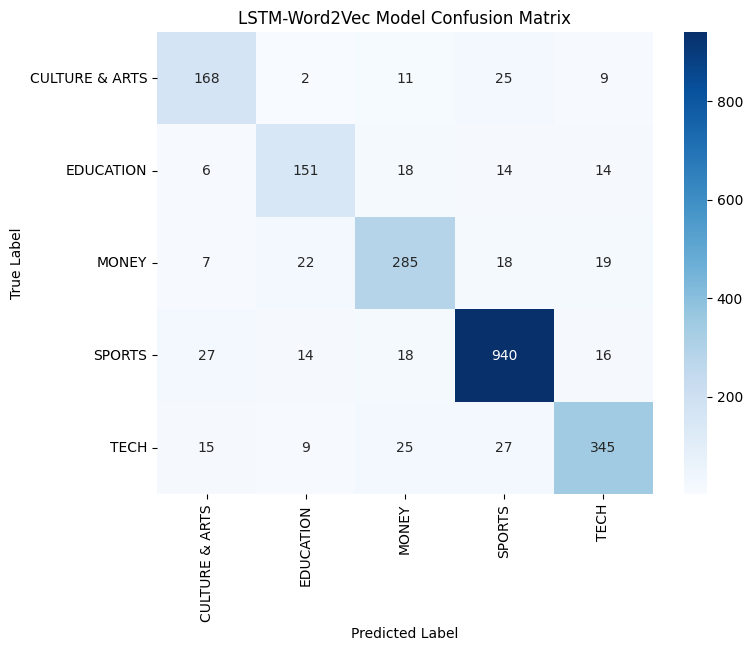

In [31]:
# Generate Confusion Matrix for LSTM-Word2Vec
conf_matrix_lstm_w2v = confusion_matrix(y_test, y_pred_lstm_w2v)

# Get class names from the LabelEncoder (assuming it's still available)
class_names = label_encoder.classes_ if 'label_encoder' in locals() else [str(i) for i in range(num_classes)]

plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix_lstm_w2v,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('LSTM-Word2Vec Model Confusion Matrix')
plt.show()

## Comparing the three models

### Model Comparison: Simple RNN vs. LSTM vs. LSTM with GloVe

In [32]:
# Gather performance metrics for all models

# Simple RNN Model Metrics
rnn_metrics = {
    'Model': 'Simple RNN',
    'Accuracy': accuracy, # From RNN evaluation
    'Training Duration (s)': training_duration # From RNN training
}

# LSTM Model Metrics
lstm_metrics = {
    'Model': 'LSTM (Trainable Embedding)',
    'Accuracy': accuracy_lstm, # From LSTM evaluation
    'Training Duration (s)': training_duration_lstm # From LSTM training
}

# LSTM with GloVe Embeddings Model Metrics
lstm_glove_metrics = {
    'Model': 'LSTM (GloVe Embeddings)',
    'Accuracy': accuracy_lstm_w2v, # From LSTM-Word2Vec evaluation
    'Training Duration (s)': training_duration_lstm_w2v # From LSTM-Word2Vec training
}

# Create a DataFrame for easy comparison
comparison_df = pd.DataFrame([rnn_metrics, lstm_metrics, lstm_glove_metrics])

print("\n--- Model Performance Comparison ---")
display(comparison_df.sort_values(by='Accuracy', ascending=False))



--- Model Performance Comparison ---


,Model,Accuracy,Training Duration (s)
2,LSTM (GloVe Embeddings),0.856689,102.296213
1,LSTM (Trainable Embedding),0.848073,65.025274
0,Simple RNN,0.819048,58.018598


---

## Error Analysis

In [41]:
# Get true labels and predictions for the Simple RNN model
y_true_rnn = y_test
y_pred_rnn_model = np.argmax(loaded_rnn_model.predict(X_test_padded), axis=1)

# Find indices where predictions are incorrect
misclassified_indices_rnn = np.where(y_true_rnn.values != y_pred_rnn_model)[0]

print(f"Total misclassified examples by Simple RNN model: {len(misclassified_indices_rnn)}")

# Select a few (e.g., 3) random misclassified examples for analysis
num_examples_to_show = 3
if len(misclassified_indices_rnn) > 0:
    sample_misclassified_indices_rnn = np.random.choice(misclassified_indices_rnn, min(num_examples_to_show, len(misclassified_indices_rnn)), replace=False)

    print("\n--- Sample Misclassified Examples (Simple RNN Model) ---")
    for i, idx in enumerate(sample_misclassified_indices_rnn):
        # Use .iloc for positional access to Series
        original_headline = df.loc[X_test.index[idx], 'headline']
        cleaned_text_sample = df.loc[X_test.index[idx], 'clean_text'] # Renamed to avoid conflict
        true_category_encoded = y_true_rnn.iloc[idx]
        predicted_category_encoded = y_pred_rnn_model[idx]

        true_category_name = label_encoder.inverse_transform([int(true_category_encoded)])[0]
        predicted_category_name = label_encoder.inverse_transform([int(predicted_category_encoded)])[0]

        print(f"\nExample {i+1}:")
        print(f"  Original Headline: {original_headline}")
        print(f"  Cleaned Text: {cleaned_text_sample}")
        print(f"  True Category: {true_category_name} (Encoded: {int(true_category_encoded)})")
        print(f"  Predicted Category: {predicted_category_name} (Encoded: {predicted_category_encoded})")
else:
    print("No misclassified examples found by the Simple RNN model.")

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Total misclassified examples by Simple RNN model: 399

--- Sample Misclassified Examples (Simple RNN Model) ---

Example 1:
  Original Headline: Who Would Replace Arne Duncan?
  Cleaned Text: would replace arne duncan
  True Category: EDUCATION (Encoded: 1)
  Predicted Category: SPORTS (Encoded: 3)

Example 2:
  Original Headline: Renting Your Road Trip: Tips to Quick Car Rentals
  Cleaned Text: renting road trip tip quick car rental
  True Category: MONEY (Encoded: 2)
  Predicted Category: TECH (Encoded: 4)

Example 3:
  Original Headline: Montana Becomes First State To Set Its Own Net Neutrality Rules
  Cleaned Text: montana becomes first state set net neutrality rule
  True Category: TECH (Encoded: 4)
  Predicted Category: SPORTS (Encoded: 3)


In [42]:
# Get true labels and predictions for the LSTM model
y_true_lstm = y_test
y_pred_lstm_model = np.argmax(loaded_lstm_model.predict(X_test_padded), axis=1)

# Find indices where predictions are incorrect
misclassified_indices = np.where(y_true_lstm.values != y_pred_lstm_model)[0]

print(f"Total misclassified examples by LSTM model: {len(misclassified_indices)}")

# Select a few (e.g., 3) random misclassified examples for analysis
num_examples_to_show = 3
if len(misclassified_indices) > 0:
    sample_misclassified_indices = np.random.choice(misclassified_indices, min(num_examples_to_show, len(misclassified_indices)), replace=False)

    print("\n--- Sample Misclassified Examples (LSTM Model) ---")
    for i, idx in enumerate(sample_misclassified_indices):
        # Use .iloc for positional access to Series
        original_headline = df.loc[X_test.index[idx], 'headline']
        cleaned_text_sample = df.loc[X_test.index[idx], 'clean_text'] # Renamed to avoid conflict
        true_category_encoded = y_true_lstm.iloc[idx]
        predicted_category_encoded = y_pred_lstm_model[idx]

        true_category_name = label_encoder.inverse_transform([int(true_category_encoded)])[0]
        predicted_category_name = label_encoder.inverse_transform([int(predicted_category_encoded)])[0]

        print(f"\nExample {i+1}:")
        print(f"  Original Headline: {original_headline}")
        print(f"  Cleaned Text: {cleaned_text_sample}")
        print(f"  True Category: {true_category_name} (Encoded: {int(true_category_encoded)})")
        print(f"  Predicted Category: {predicted_category_name} (Encoded: {predicted_category_encoded})")
else:
    print("No misclassified examples found by the LSTM model. (This is highly unlikely for real-world data).")

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Total misclassified examples by LSTM model: 335

--- Sample Misclassified Examples (LSTM Model) ---

Example 1:
  Original Headline: London's Mayor Gets to the Greek
  Cleaned Text: london mayor get greek
  True Category: CULTURE & ARTS (Encoded: 0)
  Predicted Category: EDUCATION (Encoded: 1)

Example 2:
  Original Headline: Details of Duncan Equity Equality Plan
  Cleaned Text: detail duncan equity equality plan
  True Category: EDUCATION (Encoded: 1)
  Predicted Category: CULTURE & ARTS (Encoded: 0)

Example 3:
  Original Headline: Mark Rinehart, Georgia Math Teacher, Denied Additional Paid Leave To Be With Dying Wife
  Cleaned Text: mark rinehart georgia math teacher denied additional paid leave dying wife
  True Category: MONEY (Encoded: 2)
  Predicted Category: EDUCATION (Encoded: 1)


In [43]:
# Get true labels and predictions for the LSTM with GloVe model
y_true_lstm_w2v = y_test
y_pred_lstm_w2v_model = np.argmax(loaded_lstm_w2v_model.predict(X_test_padded), axis=1)

# Find indices where predictions are incorrect
misclassified_indices_lstm_w2v = np.where(y_true_lstm_w2v.values != y_pred_lstm_w2v_model)[0]

print(f"Total misclassified examples by LSTM with GloVe model: {len(misclassified_indices_lstm_w2v)}")

# Select a few (e.g., 3) random misclassified examples for analysis
num_examples_to_show = 3
if len(misclassified_indices_lstm_w2v) > 0:
    sample_misclassified_indices_lstm_w2v = np.random.choice(misclassified_indices_lstm_w2v, min(num_examples_to_show, len(misclassified_indices_lstm_w2v)), replace=False)

    print("\n--- Sample Misclassified Examples (LSTM with GloVe Embeddings Model) ---")
    for i, idx in enumerate(sample_misclassified_indices_lstm_w2v):
        # Use .iloc for positional access to Series
        original_headline = df.loc[X_test.index[idx], 'headline']
        cleaned_text_sample = df.loc[X_test.index[idx], 'clean_text'] # Renamed to avoid conflict
        true_category_encoded = y_true_lstm_w2v.iloc[idx]
        predicted_category_encoded = y_pred_lstm_w2v_model[idx]

        true_category_name = label_encoder.inverse_transform([int(true_category_encoded)])[0]
        predicted_category_name = label_encoder.inverse_transform([int(predicted_category_encoded)])[0]

        print(f"\nExample {i+1}:")
        print(f"  Original Headline: {original_headline}")
        print(f"  Cleaned Text: {cleaned_text_sample}")
        print(f"  True Category: {true_category_name} (Encoded: {int(true_category_encoded)})")
        print(f"  Predicted Category: {predicted_category_name} (Encoded: {predicted_category_encoded})")
else:
    print("No misclassified examples found by the LSTM with GloVe model.")

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Total misclassified examples by LSTM with GloVe model: 316

--- Sample Misclassified Examples (LSTM with GloVe Embeddings Model) ---

Example 1:
  Original Headline: New Video Questions False Promises of Online Education Industry
  Cleaned Text: new video question false promise online education industry
  True Category: EDUCATION (Encoded: 1)
  Predicted Category: TECH (Encoded: 4)

Example 2:
  Original Headline: Cheapest U.S. Cities Located In Texas, Tennessee
  Cleaned Text: cheapest yous city located texas tennessee
  True Category: MONEY (Encoded: 2)
  Predicted Category: EDUCATION (Encoded: 1)

Example 3:
  Original Headline: 7 Surprising Household Items That Invade Your Privacy
  Cleaned Text: surprising household item invade privacy
  True Category: TECH (Encoded: 4)
  Predicted Category: MONEY (Encoded: 2)


## GUI for Real Time Prediction

In [46]:
# Re-define the clean_text function to ensure it is not overwritten.
# This definition is copied from the original cell 'a1008493'.
import re
import contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Initialize lemmatizer and stopwords (if not already initialized in the session)
# Defensive re-initialization
if 'lemmatizer' not in globals():
    lemmatizer = WordNetLemmatizer()
if 'stop_words' not in globals():
    stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ''

    # 1. Handle contractions
    text = contractions.fix(text)

    # 2. Lowercase all text
    text = text.lower()

    # 3. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 4. Remove mentions (@user)
    text = re.sub(r'@\w+', '', text)

    # 5. Remove hashtags (#)
    text = re.sub(r'#\w+', '', text)

    # 6. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 7. Remove special characters (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 8. Remove stopwords and lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    text = ' '.join(tokens)

    # 9. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

print('Text cleaning function re-defined to ensure availability for Gradio.')

Text cleaning function re-defined to ensure availability for Gradio.


In [44]:
# Install Gradio if not already installed
!pip install gradio --quiet

import gradio as gr

# Load the best performing model based on comparison (LSTM with GloVe Embeddings)
try:
    best_model_path = os.path.join(model_save_dir, 'best_LSTM_Word2Vec_model.keras')
    loaded_model = load_model(best_model_path)
    print(f"Successfully loaded model from: {best_model_path}")
except Exception as e:
    print(f"Error loading model: {e}")
    print("Please ensure the model was trained and saved correctly.")
    loaded_model = None # Set to None to handle cases where model loading fails

Successfully loaded model from: /content/drive/MyDrive/AI ML/Models/best_LSTM_Word2Vec_model.keras


In [47]:
if loaded_model is not None:
    # Define the prediction function for Gradio
    def predict_category(text):
        # 1. Clean the input text
        cleaned_text = clean_text(text)

        # 2. Tokenize the cleaned text
        sequence = tokenizer.texts_to_sequences([cleaned_text])

        # 3. Pad the sequence
        padded_sequence = pad_sequences(sequence, maxlen=max_sequence_len, padding='pre')

        # 4. Make prediction using the loaded model
        prediction_proba = loaded_model.predict(padded_sequence)[0]
        predicted_class_encoded = np.argmax(prediction_proba)

        # 5. Inverse transform to get the category name
        predicted_category_name = label_encoder.inverse_transform([predicted_class_encoded])[0]

        return predicted_category_name

    # Create the Gradio interface
    iface = gr.Interface(
        fn=predict_category,
        inputs=gr.Textbox(lines=2, placeholder="Enter a news headline here..."),
        outputs="text",
        title="News Headline Category Predictor",
        description="Enter a news headline and get its predicted category in real-time."
    )

    # Launch the interface
    print("Launching Gradio interface...")
    iface.launch(debug=True)
else:
    print("Cannot launch Gradio interface as no model was loaded.")

Launching Gradio interface...
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://44bb65322b45a63f87.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://44bb65322b45a63f87.gradio.live
